<a href="https://colab.research.google.com/github/bilqis637/UTS_Datamining/blob/main/UTS_DATMIN(1)_2304020126.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Persiapan Data**

In [2]:
# import library
import pandas as pd
import numpy as np

In [3]:
train = pd.read_csv('data_training.csv')
test = pd.read_csv('data_testing.csv')

In [4]:
train.head()
test.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


In [5]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (857, 13)
Test shape: (286, 12)


In [6]:
train.info()
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data c

In [ ]:
train.isnull().sum()
test.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
train.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


**Pembersihan Data**

In [ ]:
print("Missing value - Train:")
print(train.isnull().sum())

print("\nMissing value - Test:")
print(test.isnull().sum())

Missing value - Train:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Missing value - Test:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64


Berdasarkan hasil pengecekan, tidak ditemukan missing value pada dataset, sehingga tidak diperlukan proses imputasi atau penghapusan data.

**Pembuatan Model**

1. Random Forest Classier

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X = train.drop(['Id', 'quality'], axis=1)
y = train['quality']

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Data dibagi menjadi data training dan data validation untuk menguji performa model sebelum digunakan pada data testing

In [14]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [16]:
y_pred_rf = model.predict(X_val)

In [18]:
print("Accuracy:", accuracy_score(y_val, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_rf))

Accuracy: 0.6104651162790697
Confusion Matrix:
 [[ 0  1  2  0  0]
 [ 0 44 23  0  0]
 [ 0 22 53  3  0]
 [ 0  2 11  8  0]
 [ 0  0  0  3  0]]


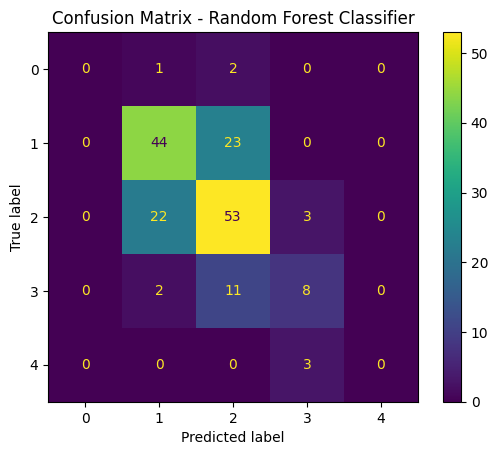

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm_rf = confusion_matrix(y_val, y_pred_rf) # Calculate the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title("Confusion Matrix - Random Forest Classifier")
plt.show()

Berdasarkan model Random Forest Classifier diperoleh nilai akurasi sebesar 0.6104651162790697.

2. Model KNN

In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [26]:
# Scaling
scaler_knn = StandardScaler()

X_train_knn = scaler_knn.fit_transform(X_train)
X_val_knn = scaler_knn.transform(X_val)

In [ ]:
# Training model KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_knn, y_train)

KNeighborsClassifier()

In [ ]:
y_pred_knn = knn.predict(X_val_knn)

In [ ]:
print("Accuracy KNN:", accuracy_score(y_val, y_pred_knn))
print("Confusion Matrix KNN:\n", confusion_matrix(y_val, y_pred_knn))

Accuracy KNN: 0.4941860465116279
Confusion Matrix KNN:
 [[ 0  1  2  0  0]
 [ 3 35 29  0  0]
 [ 0 30 41  5  2]
 [ 0  4  8  9  0]
 [ 0  0  0  3  0]]


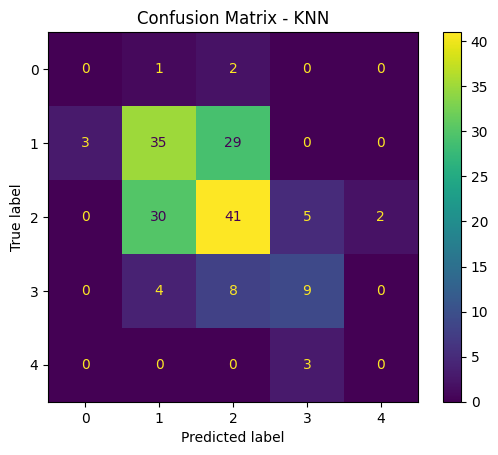

In [ ]:
cm_knn = confusion_matrix(y_val, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp.plot()
plt.title("Confusion Matrix - KNN")
plt.show()

Berdasarkan model KNN diperoleh nilai akurasi sebesar 0.4941860465116279.

3. Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_dt = dt.predict(X_val)

In [ ]:
cm = confusion_matrix(y_val, y_pred_dt)
print("Accuracy Decision Tree:", accuracy_score(y_val, y_pred_dt))
print("\nConfusion Matrix:\n", cm)

Accuracy Decision Tree: 0.45348837209302323

Confusion Matrix:
 [[ 0  0  0  0  0  0]
 [ 0  0  2  1  0  0]
 [ 0  0 31 33  3  0]
 [ 1  3 21 40 12  1]
 [ 0  0  3  9  7  2]
 [ 0  0  0  1  2  0]]


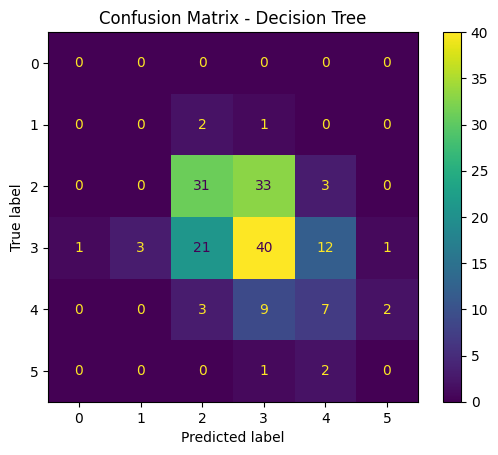

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

Bedasarkan model Decision Tree diperoleh nilai akurasi sebesar 0.45348837209302323.

4. Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred_nb = nb.predict(X_val)

In [ ]:
cm_nb = confusion_matrix(y_val, y_pred_nb)
print("Accuracy Naive Bayes:", accuracy_score(y_val, y_pred_nb))
print("\nConfusion Matrix Naive Bayes:\n", cm_nb)

Accuracy Naive Bayes: 0.48255813953488375

Confusion Matrix Naive Bayes:
 [[ 1  1  1  0  0]
 [ 1 34 31  1  0]
 [ 0 18 39 14  7]
 [ 0  1  8  9  3]
 [ 0  0  0  3  0]]


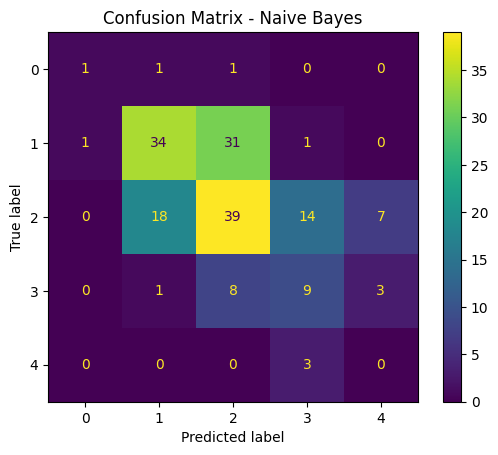

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb)
disp.plot()
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

Berdasarkan model Naive Baye diperoleh nilai akurasi sebesar 0.48255813953488375.

5. Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
#Scaling
scaler_lr = StandardScaler()
X_train_lr = scaler_lr.fit_transform(X_train)
X_val_lr = scaler_lr.transform(X_val)

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scaling (moved from nnctUQVU2pfA)
scaler_lr = StandardScaler()
X_train_lr = scaler_lr.fit_transform(X_train)
X_val_lr = scaler_lr.transform(X_val)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_lr, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_lr = lr.predict(X_val_lr)

In [ ]:
cm_lr = confusion_matrix(y_val, y_pred_lr)
print("Accuracy Logistic Regression:", accuracy_score(y_val, y_pred_lr))
print("\nConfusion Matrix Logistic Regression:\n", cm_lr)


Accuracy Logistic Regression: 0.5988372093023255

Confusion Matrix Logistic Regression:
 [[ 0  3  0  0  0]
 [ 0 55 12  0  0]
 [ 0 29 42  6  1]
 [ 0  1 14  6  0]
 [ 0  0  0  3  0]]


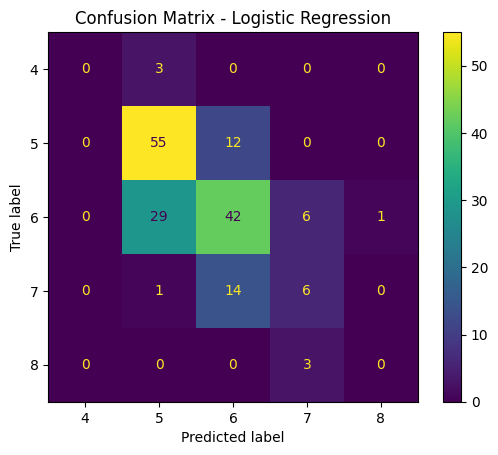

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=np.unique(y_val))
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Berdasarkan model Logistic Regression diperoleh nilai akurasi sebesar  0.5988372093023255.

6. Model SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [ ]:
#Scaling
scaler_svm = StandardScaler()
X_train_svm = scaler_svm.fit_transform(X_train)
X_val_svm = scaler_svm.transform(X_val)


In [32]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Scaling (moved from DtqBDp15uOw8)
scaler_svm = StandardScaler()
X_train_svm = scaler_svm.fit_transform(X_train)
X_val_svm = scaler_svm.transform(X_val)

svm = SVC()
svm.fit(X_train_svm, y_train)

SVC()

In [ ]:
y_pred_svm = svm.predict(X_val_svm)

In [ ]:
cm_svm = confusion_matrix(y_val, y_pred_svm)
print("Accuracy SVM:", accuracy_score(y_val, y_pred_svm))
print("\nConfusion Matrix SVM:\n", cm_svm)

Accuracy SVM: 0.5697674418604651

Confusion Matrix SVM:
 [[ 0  3  0  0  0]
 [ 0 49 18  0  0]
 [ 0 29 42  7  0]
 [ 0  3 11  7  0]
 [ 0  0  1  2  0]]


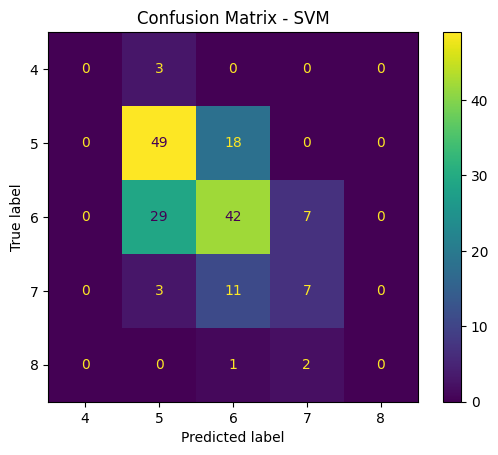

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=np.unique(y_val))
disp.plot()
plt.title("Confusion Matrix - SVM")
plt.show()

Berdasarkan model SVM diperoleh nilai akurasi Sebesar 0.5697674418604651.


In [ ]:
print("=== PERBANDINGAN MODEL ===")
print("Random Forest:", accuracy_score(y_val, y_pred_rf))
print("KNN:", accuracy_score(y_val, y_pred_knn))
print("Decision Tree:", accuracy_score(y_val, y_pred_dt))
print("Naive Bayes:", accuracy_score(y_val, y_pred_nb))
print("SVM:", accuracy_score(y_val, y_pred_svm))
print("Logistic Regression:", accuracy_score(y_val, y_pred_lr))

=== PERBANDINGAN MODEL ===
Random Forest: 0.6104651162790697
KNN: 0.4941860465116279
Decision Tree: 0.45348837209302323
Naive Bayes: 0.48255813953488375
SVM: 0.5697674418604651
Logistic Regression: 0.5988372093023255


Kesimpulan: Berdasarkan 6 model klasifikasi yang sudah dianalisis, pemilihan model terbaik adalah model Random Forest karena memiliki nilai akurasi paling tinggi yaitu sebesar 0.6104651162790697. Jadi, kita menggunakan model Random Forest Classifier untuk memprediksi data.

**Prediksi Data Testing**

In [9]:
X_test = test.drop(['Id'], axis=1)

In [22]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
test_pred = model.predict(test.drop('Id', axis=1))

In [23]:
result = pd.DataFrame({
    'Id': test['Id'],
    'Quality': test_pred
})
result.head()

,Id,Quality
0,222,5
1,1514,5
2,417,5
3,754,5
4,516,5


In [ ]:
print(result)

       Id  Quality
0     222        5
1    1514        5
2     417        5
3     754        5
4     516        5
..    ...      ...
281  1147        5
282   296        5
283   170        5
284  1439        5
285   946        7

[286 rows x 2 columns]


In [ ]:
result['Quality'].value_counts()

,count
Quality,
5,136
6,120
7,30


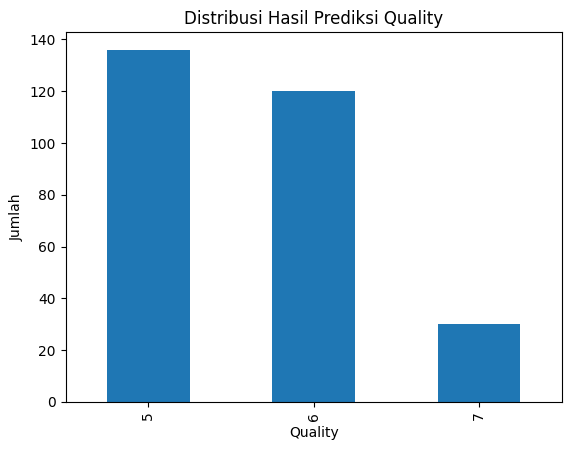

In [ ]:
import matplotlib.pyplot as plt

result['Quality'].value_counts().plot(kind='bar')
plt.title("Distribusi Hasil Prediksi Quality")
plt.xlabel("Quality")
plt.ylabel("Jumlah")
plt.show()

In [25]:
result.to_csv('hasilprediksi_126.csv', index=False)